# COCO images + captions preprocessing pipeline 

Authors:

data team : Mohamad Sizar

training team (transformer): Nacef Amine, Mimouni Nassim

training team (CNN): Bouhadda Younes, Rezzoug Sid Ali

# Explaining The Input Formats

We have two types of inputs:
1. images
2. annotations (captions text)

> the images have a JPEG format
the annotations are stored in a JSON format

# Step 1 : Extract The Data As JSONL
## Understanding The Structure Of Data In The JSON File

we will use `ujson` library as a JSON praser because it is faster than the built-in python library.


In [1]:
import ujson
import threading

def extract_annotations():
    with open("annotation_objects_training.jsonl", "a") as f:
        for element in raw_input_data["annotations"]:
            ujson.dump(element, f)
            f.write("\n")

def extract_image_metadata():
    with open("image_objects_train.jsonl", "a") as f:
        for element in raw_input_data["images"]:
            ujson.dump(element, f)
            f.write("\n")

In [2]:
# captions_file_dir = "captions_train2017.json"
captions_file_dir = "captions_val2017.json"

with open(captions_file_dir , "r") as f:
    raw_input_data = ujson.load(f)

t1 = threading.Thread(target=extract_annotations)
t2 = threading.Thread(target=extract_image_metadata)

t1.start()
t2.start()

t1.join()
t2.join()

print("Done")

Done


the coco annotations json files contains the same structure :

* `info` object which has the general infomration on the dataset
* `licenses` list of objects contains the licenses
* `images` list of objects contains images meta-data
* `annotations` list of ojbects contains the captions with the associated image_id

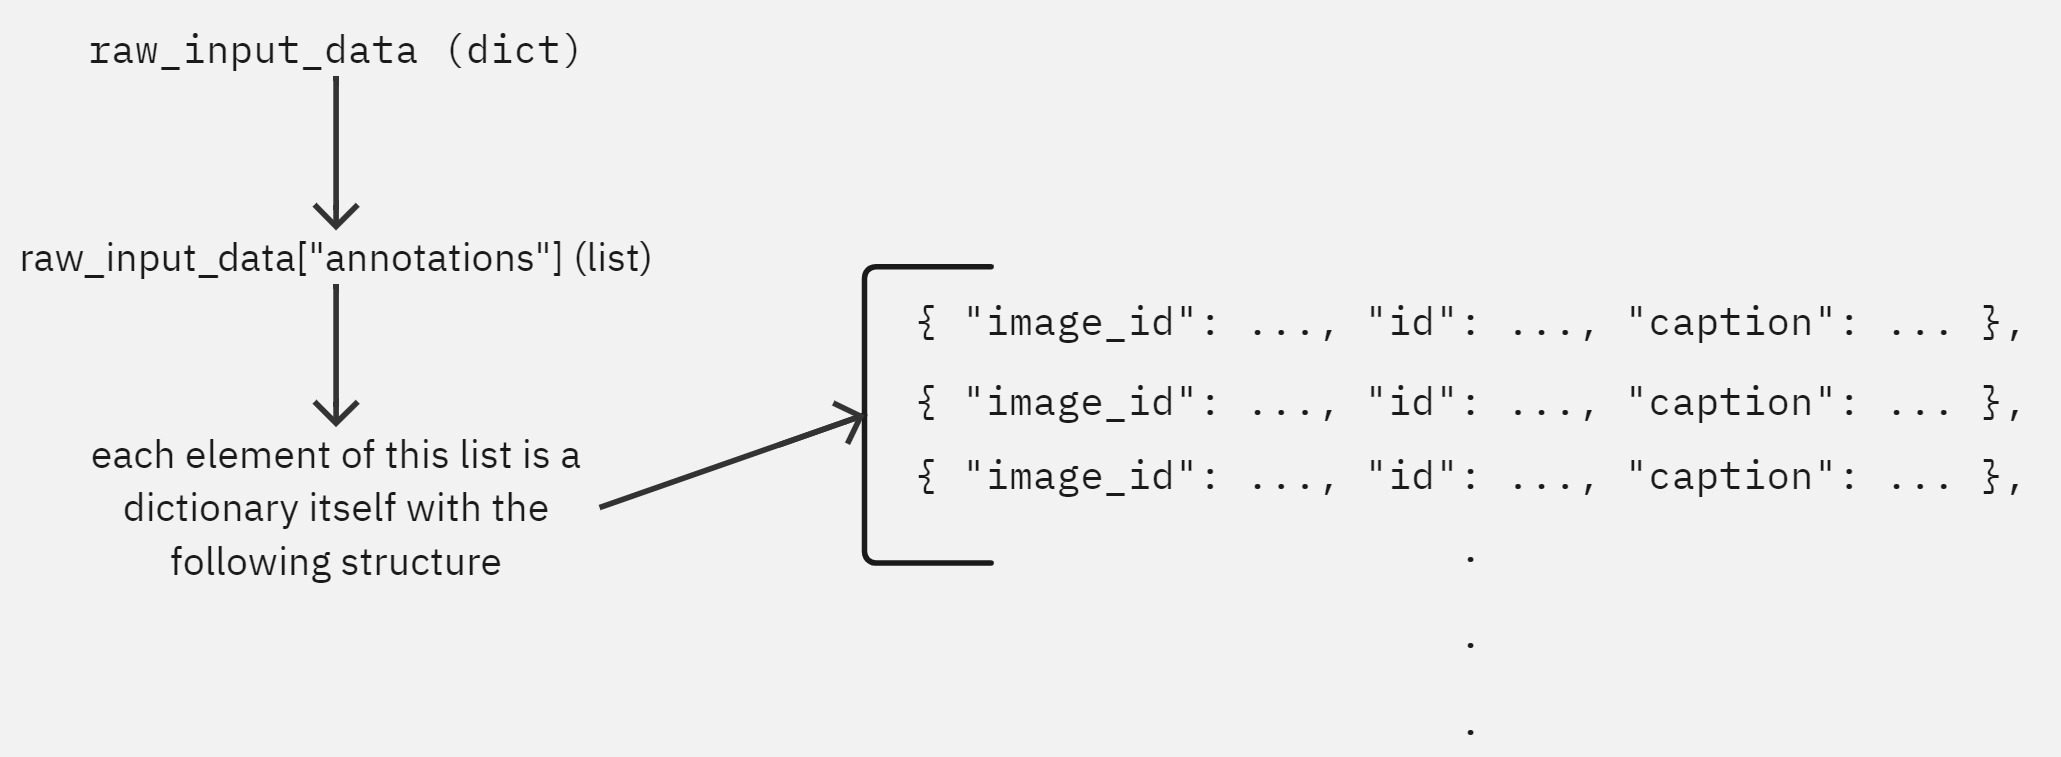
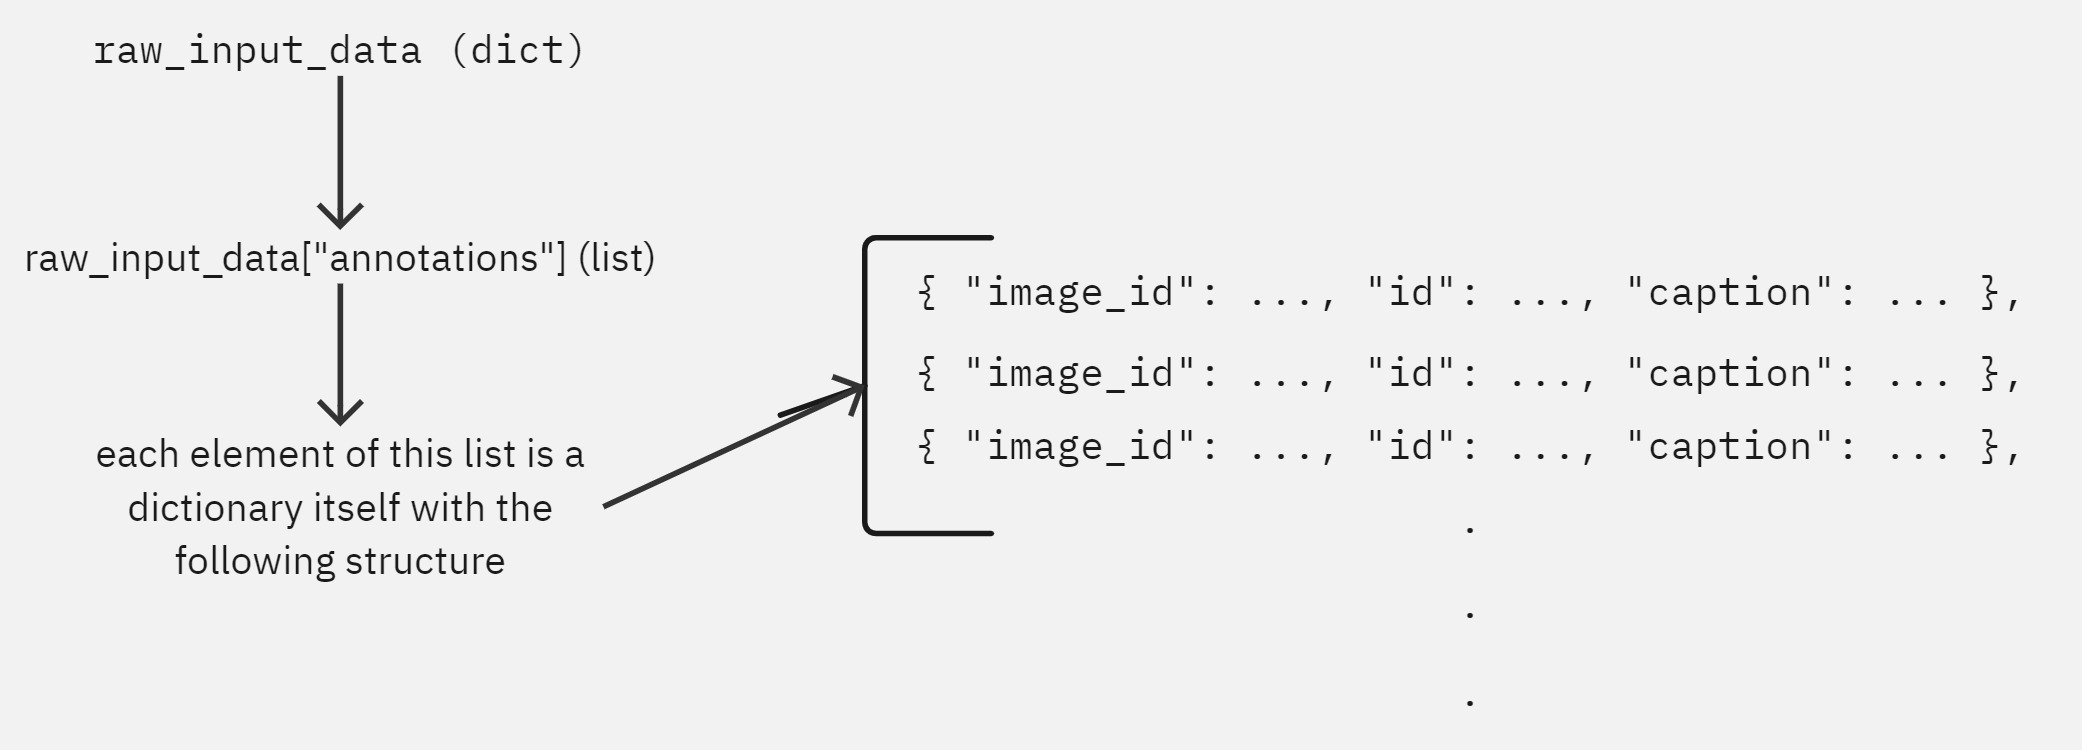

## Streaming Approach
Since the size of the files are considerably large, we chose to follow a streaming approach instead of loading the entire JSON file to memory.

To do so we extracted the images meta-data and the captions form the orginal coco files and put each one of them in a seperate **JSONL** file.

JSONL (JSON Line) is similar to JSON with one difference which is : each line will contain only one JSON object, using JSONL will facilitate the streaming (line by line processing) pipline.

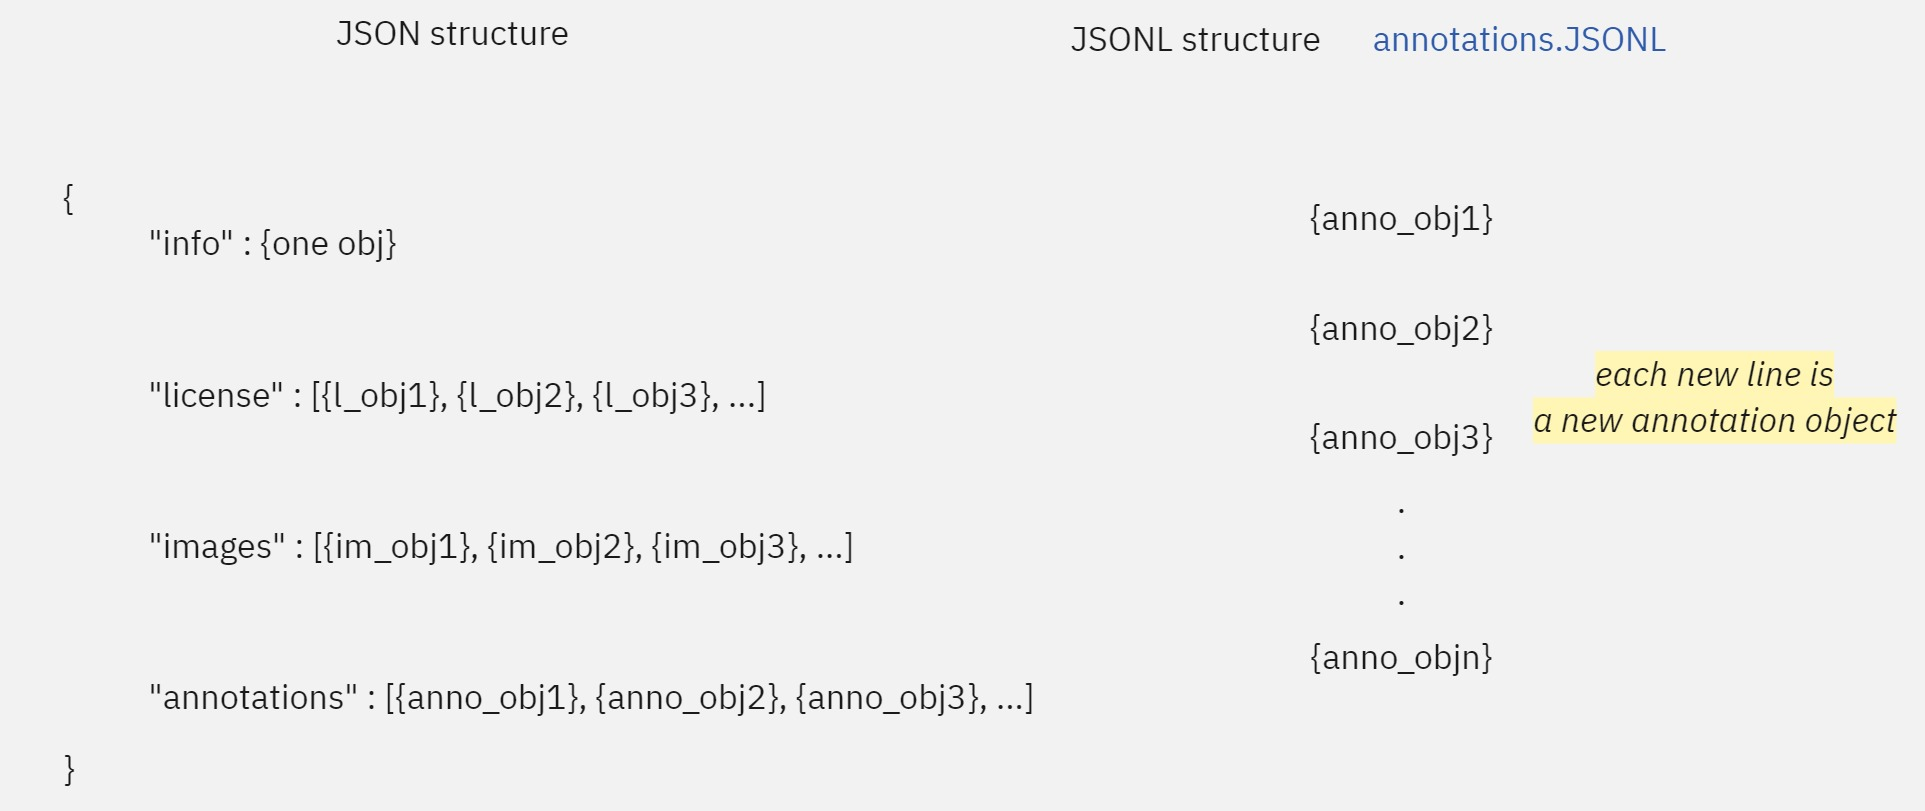

# Step 2 : Text Preprocessing

## Expected Output
The goal of this step is to produce a JSONL file for each phase (training, validation, testing) that contains :
> image_id, caption_id, caption

the caption must follow these constraintes :
1. tokenization is limited to the most frequent 10_000 words
2. we add the special tokens
   > `<start>, <end>, <unk>, <pad>`
4. the maximum length of each caption is 20 token
5. the caption must be int encoded

output example:
> encoded caption :
> `{"image_id":203564,"id":37,"caption":[1,4,355,3781,9,4,83,121,7,40,1083,0,0,0,0,0,0,0,0,2]}`

string caption :
> `{"image_id":203564,"id":37,"caption":["<start>","a","bicycle","replica","with","a","clock","as","the","<unk>","wheel","<pad>","<end>"]}`


## Explaining the caption preprocessing pipline
>We will start by explaining the general pipline then we explain each helper function.

This script process 3 *JSONL* files : the input, the intermediate output, the final output.

We will read each line and extract the caption to tokenize it, normalize it, and at the same time we calculate the frequency of each read word, then we dump the processed line into the intermediate output JSONL file.

### Creating helper dictionaries

Before processing the intermediate output we create three helper dictionaries based on the words frequencies
1. a dict that maps token to word that contains the top 10_000 used words
2. a dict that maps token to its id
3. a dict that maps token_id to it token
### Processing the intermediate output
Simply we open a new *JSONL* file as the final output then we dump in it the encoded captions extracted from the intermediate output file.

In [9]:
def remove_nonalpha_and_single_char_tokens(sentence,consider_1letter_words):
    i = 0
    while i < len(sentence):
        word = sentence[i]
        if consider_1letter_words:
            if (not word.isalpha()):
                sentence.pop(i)
            else:
                i = i+1 
        else:
            if (not word.isalpha()) or (len(word) == 1):
                sentence.pop(i)
            else:
                i = i+1 
    return sentence

## `remove_nonalpha_and_single_char_tokens`
input : list of tokens and a boolean that instruct the function to add one-letter tokens to the output token list or not. (example : "a man", "man's phone", the "a" and the "s" are one letter words) 

output : list of strings that doesn't contain any special characterss.

Algorithm : 
1. we take a list of tokens as an argument (a sentence)
2. we take a word form that sentence
3. if we do consider one letter tokens we only check for one conditions whcih is `word.isalpha()` if it is not we pop the token form the token list
4. if we don't consider one letter tokens we add to the pop condition `len(word) == 1`

In [10]:
import re
# input : "Sizar's ,Phone" -> output : ["sizar", "'", "s", ",", "phone", "."]
# loops over one caption
def basic_tokenizer(caption):
    caption_tokens = caption.lower().split()
    i = 0
    while (i < len(caption_tokens)):
        original_word = caption_tokens[i]
        if (not original_word.isalpha()) and len(original_word) > 1:

            match_object = re.search(r"[^a-zA-Z]", original_word)

            # token1 = "" -> non letter is at the beginning
            # token1 = word -> non letter is in the middle
            # token1 = original word -> non letter is at the end

            token1 = original_word[:match_object.span()[0]]

            match token1:
                case "":
                    token1 = original_word[match_object.span()[0]]
                    token2 = original_word[match_object.span()[0]+1:]
                case _ if token1 == original_word:
                    token1 = original_word[match_object.span()[0]]
                    token2 = original_word[:match_object.span()[0]-1]
                case _:
                    token2 = original_word[match_object.span()[0]:]

            caption_tokens.pop(i)
            caption_tokens.insert(i, token1)
            caption_tokens.insert(i+1, token2)
        i = i+1
    return caption_tokens  

## `basic_tokenizer(caption)`

**Input:**

* `caption`: a string (one image caption).
  Example: `"Sizar's ,Phone."`

**Output:**

* A list of lowercase tokens where **alphabetic parts are separated from non-alphabetic characters** (punctuation/symbols).

  Example: `["sizar", "'", "s", ",", "phone", "."]`

**Algorithm:**

1. Convert the caption to lowercase, then split it by whitespace to get an initial token list.
2. Loop through the token list using an index `i`.
3. For each token `original_word`:

   * If the token is **not purely alphabetic** (`not original_word.isalpha()`) and its length is greater than 1, then:

     1. Find the **first non-letter character** inside it using a regex search (`[^a-zA-Z]`).
     2. Split the token into two parts around that first non-letter position:

        * `token1`: substring before the first non-letter character.
        * `token2`: substring starting at (or around) that non-letter character, depending on where it occurs.
     3. Handle three cases:

        * **Non-letter at the beginning**: make `token1` the non-letter character, and `token2` the remaining substring after it.
        * **Non-letter at the end**: make `token1` the non-letter character, and `token2` the alphabetic part before it.
        * **Non-letter in the middle**: keep `token1` as the alphabetic prefix, and `token2` as the rest starting from the non-letter character.
     4. Replace the original token in the list by removing it (`pop`) and inserting `token1` then `token2` at the same position.
4. Continue until all tokens have been processed.
5. Return the resulting token list.


In [11]:
def frequency_analysis(dict_source):
    # create a dict of most frequent words and sort them
    sorted_words_by_frequency = dict(sorted(dict_source.items(),
                                            key=lambda item: item[1],
                                            reverse=True))
    
    # convert to list to keep only the most frequent 10_000 words
    list_10_000_frequent_words = list(sorted_words_by_frequency.keys())
    list_10_000_frequent_words = list_10_000_frequent_words[:10_000]
    
    # creat a dictionary with {word:word} and replace any words outside of this
    # dict with <unk>
    dict_token_word = {word:word for word in list_10_000_frequent_words}
    
    # dict token:id
    dict_token_id = {word:index for index, word in enumerate(list_10_000_frequent_words, start=4)}
    dict_token_id.update({"<pad>":0, "<start>":1, "<end>":2, "<unk>":3})
    
    # dict id:token
    dict_id_token = {index:word for index, word in enumerate(list_10_000_frequent_words, start=4)}
    dict_id_token.update({0:"<pad>", 1:"<start>", 2:"<end>", 3:"<unk>"})
    
    # export the word_dictionary so it can be used later with valid and test datasets
    with open("dict_token_word.json", "w") as fout1:
        ujson.dump(dict_token_word, fout1, indent=4)
    
    with open("dict_token_id.json","w") as fout2:
        ujson.dump(dict_token_id, fout2, indent=4)
        
    with open("dict_id_token.json","w") as fout3:
        ujson.dump(dict_id_token, fout3, indent=4)

## `frequency_analysis(dict_source)`

**Input:**

* `dict_source`: a dictionary containing words and their frequencies in the training captions.
  Structure:

  ```
  {word : frequency}
  ```

**Output:**
This function does not return a value but generates and exports three dictionaries used during the encoding phase:

1. `dict_token_word.json`
   Structure:

   ```
   {word : word}
   ```

   Used to check whether a token belongs to the **10,000 most frequent words**.

2. `dict_token_id.json`
   Structure:

   ```
   {token : id}
   ```

   Used to convert tokens into **numerical IDs**.

3. `dict_id_token.json`
   Structure:

   ```
   {id : token}
   ```

   Used to convert **IDs back into tokens**.

**Algorithm:**

1. Take the dictionary containing the word frequencies (`dict_source`).
2. Sort the dictionary by frequency in **descending order** so that the most frequent words appear first.
3. Extract the sorted words and convert them into a list.
4. Keep only the **10,000 most frequent words** from this list to construct the vocabulary.
5. Create a dictionary `dict_token_word` with the structure `{word : word}` for the selected vocabulary.
   This dictionary is later used to replace any word outside this vocabulary with the `<unk>` token.
6. Create a dictionary `dict_token_id` that assigns a **unique integer ID** to each word using enumeration.

   * IDs start from **4**.
   * The first four IDs are reserved for special tokens:

     ```
     <pad>   → 0
     <start> → 1
     <end>   → 2
     <unk>   → 3
     ```
7. Create the reverse dictionary `dict_id_token` that maps each ID back to its corresponding token.
8. Export the three dictionaries to JSON files so they can later be reused when preprocessing the **validation and test datasets**.


In [ ]:
def encode_captions(caption, word_dictionary, id_dictionary=None):
    # create a copy of caption to avoid errors
    new_caption = [] 
    
    # replace words outside of this dict with <unk>
    for index, word in enumerate(caption):
        new_caption.append(word_dictionary.get(word, "<unk>"))
    
    # add <pad> to captions < 18
    if len(new_caption) < 18:
        i = len(new_caption)
        while(i < 18):
            new_caption.append("<pad>")
            i = i+1 
    else: # slice to 18 if caption >= 18
        new_caption = new_caption[:18]
    
    # insert the <start> and <end> special tokens
    new_caption.insert(0, "<start>")
    new_caption.append("<end>")
    
    
    # DEBUG : comment this snippet to see the tokens not their ids
    # numericalize caption
    if id_dictionary != None:
        for index, token in enumerate(new_caption):
            new_caption[index] = id_dictionary.get(token)
    
    return new_caption

## `encode_captions(caption, word_dictionary, id_dictionary=None)`

**Input:**

* `caption`: a list of tokens representing one caption after tokenization.
  Example:

  ```
  ["a", "man", "holding", "a", "phone"]
  ```
* `word_dictionary`: a dictionary containing the allowed vocabulary (the **10,000 most frequent words**).
  Structure:

  ```
  {word : word}
  ```
* `id_dictionary` (optional): a dictionary mapping tokens to their corresponding numerical IDs.
  Structure:

  ```
  {token : id}
  ```

**Output:**

* A processed caption that:

  * contains only vocabulary words or `<unk>`
  * has a fixed length
  * includes special tokens
* If `id_dictionary` is provided, the output is a **list of token IDs** instead of tokens.

Example output (tokens):

```
["<start>", "a", "man", "holding", "a", "phone", "<pad>", ..., "<end>"]
```

Example output (IDs):

```
[1, 54, 102, 430, 54, 980, 0, ..., 2]
```

**Algorithm:**

1. Create an empty list `new_caption` to store the processed caption.
2. Loop through each word in the input caption.
3. For every word:

   * Check if the word exists in the vocabulary dictionary (`word_dictionary`).
   * If it exists, keep it.
   * Otherwise replace it with the special token `<unk>`.
4. After replacing unknown words, ensure the caption has a fixed length:

   * If the caption length is **less than 18 tokens**, add `<pad>` tokens until the length reaches 18.
   * If the caption length is **greater than or equal to 18 tokens**, truncate it to the first 18 tokens.
5. Insert the `<start>` token at the beginning of the caption.
6. Append the `<end>` token at the end of the caption.
7. If an ID dictionary is provided (`id_dictionary != None`):

   * Convert each token in the caption into its corresponding numerical ID using the dictionary.
8. Return the resulting caption.


In [ ]:
if __name__ == "__main__":
    
    from pathlib import Path
    
    # input_directory = "annotations_metadata_training.jsonl"
    input_directory = "annotations_metadata_vali.jsonl"

    intermediate_output_directory = "annotations_caption_tokenized.jsonl"
    frequency_results_directory = Path("dict_token_word.json")
    
    if input_directory == "annotations_metadata_training.jsonl":
        processing_training_dataset = True
        
    elif frequency_results_directory.is_file():
        processing_training_dataset = False
        frequency_resutls_available = True
        intermediate_output_directory = "annotations_val_test_caption_tokenized.jsonl"
    else:
        raise ValueError("frequency study results is not available")
    
    words_frequenceis = {}
    with open(input_directory, "r") as fin,\
         open(intermediate_output_directory, "w") as fout:
        for line in fin:
            
            # normalization
            obj = ujson.loads(line)
            caption = obj["caption"]
            caption = basic_tokenizer(caption)
            caption = remove_nonalpha_and_single_char_tokens(caption,True)
            i = 0
            
            # count word frequency
            while (i < len(caption)):
                word = caption[i]
                words_frequenceis[word] = words_frequenceis.get(word, 0) + 1
                i = i + 1
            
            # output the object
            obj["caption"] = caption
            ujson.dump(obj, fout)
            fout.write("\n")

    frequency_analysis(words_frequenceis)    
    
    if processing_training_dataset:
        output_directory = "preprocessed_training_dataset.jsonl"
        
    elif frequency_resutls_available:
        output_directory = "preprocessed_validation_test_dataset.jsonl"
    else:
        raise ValueError("frequency study results is not available")
    
    with open("dict_token_word.json","r") as fin1:
        dict_token_word = ujson.load(fin1)
        
    with open("dict_token_id.json","r") as fin2:
        dict_token_id = ujson.load(fin2)
    
    with open(intermediate_output_directory, "r") as fin,\
        open(output_directory,"w") as fout:
        for line in fin:
            obj = ujson.loads(line)
            caption = obj["caption"]
            
            encoded_caption = encode_captions(caption, dict_token_word, dict_token_id)
            # encoded_caption = encode_captions(caption, dict_token_word, None)

            
            obj["caption"] = encoded_caption
            ujson.dump(obj, fout)
            fout.write("\n")


Done.


## Main preprocessing pipeline (script entry point)

**Purpose:**
This block is the main execution pipeline that preprocesses captions from a COCO-style JSONL file. It performs tokenization + filtering, computes word frequencies, builds the vocabulary dictionaries using only training dataset, then encodes captions into fixed-length token IDs and exports a final preprocessed JSONL dataset.

---

### Input

* `input_directory`: path to a JSONL file where **each line is a JSON object** containing at least a `"caption"` field.
  Examples used in the script:

  * Training: `extracted_data/training_extracted_data/annotations_metadata_training.jsonl`
  * Validation: `extracted_data/vali_extracted_data/annotations_metadata_vali.jsonl`

* External resources (depending on the mode):

  * If processing validation/test: existing frequency/vocabulary outputs must already exist:

    * `dict_token_word.json`
    * `dict_token_id.json`

---

### Output

The script produces multiple files:

1. **Intermediate tokenized captions JSONL**

   * Training case: `annotations_caption_tokenized.jsonl`
   * Validation/Test case: `annotations_val_test_caption_tokenized.jsonl`
     Each line is the same JSON object but with `"caption"` replaced by a **list of cleaned tokens**.

2. **Vocabulary / encoding dictionaries (JSON)**

   * `dict_token_word.json` (vocabulary membership dict)
   * `dict_token_id.json` (token → id)
   * `dict_id_token.json` (id → token)
     These are created by `frequency_analysis(...)` (intended primarily for the training dataset, then reused for validation/test).

3. **Final preprocessed dataset JSONL**

   * Training case: `preprocessed_training_dataset.jsonl`
   * Validation/Test case: `preprocessed_validation_test_dataset.jsonl`
     Each line contains the JSON object where `"caption"` becomes a **fixed-length encoded sequence** (token IDs if `dict_token_id` is used).

---

### Algorithm

#### A) Determine processing mode (training vs validation/test)

1. Define:

   * `input_directory` (the dataset to preprocess)
   * `intermediate_output_directory` (tokenized output file)
   * `frequency_results_directory = Path("dict_token_word.json")`
2. If `input_directory` points to the training annotations file:

   * Set `processing_training_dataset = True`
3. Else if `dict_token_word.json` already exists:

   * Set `processing_training_dataset = False`
   * Set `frequency_resutls_available = True`
   * Change intermediate output name to `annotations_val_test_caption_tokenized.jsonl`
4. Otherwise:

   * Raise an error because validation/test preprocessing requires the training vocabulary results.

#### B) Tokenize captions + compute word frequencies + write intermediate JSONL

5. Initialize an empty dictionary `words_frequenceis = {}`.
6. Read the input JSONL line by line:

   1. Parse the line into `obj`.
   2. Extract `caption = obj["caption"]`.
   3. Apply caption preprocessing:

      * `basic_tokenizer(caption)` (splits punctuation/non-letters into separate tokens)
      * `remove_nonalpha_and_single_char_tokens(caption, True)` (removes non-alphabetic tokens; keeps 1-letter tokens because `True`)
   4. Count frequencies: for each token in the caption, increment its counter in `words_frequenceis`.
   5. Replace `obj["caption"]` with the token list.
   6. Write the updated object to the intermediate JSONL file (one JSON per line).

#### C) Build / export vocabulary dictionaries

7. Run `frequency_analysis(words_frequenceis)` to:

   * sort tokens by frequency
   * keep the top 10,000
   * create vocabulary and ID mappings
   * export them to JSON files for reuse

#### D) Select final output filename based on mode

8. If processing training:

   * `output_directory = "preprocessed_training_dataset.jsonl"`
9. Else if frequency results are available (validation/test case):

   * `output_directory = "preprocessed_validation_test_dataset.jsonl"`
10. Else:

* Raise an error (safety check).

#### E) Encode captions into fixed-length sequences and export final JSONL

11. Load:

* `dict_token_word` from `dict_token_word.json`
* `dict_token_id` from `dict_token_id.json`

12. Read the intermediate tokenized JSONL line by line:
13. Parse each object.
14. Get the token list `caption = obj["caption"]`.
15. Encode it using:

    * `encode_captions(caption, dict_token_word, dict_token_id)`
      (replaces out-of-vocab tokens with `<unk>`, pads/truncates, adds `<start>/<end>`, then converts tokens to IDs)
16. Replace `obj["caption"]` with the encoded sequence.
17. Write the updated object to the final output JSONL file.

**Note (debug option in the code):**
If we call `encode_captions(caption, dict_token_word, None)` instead, the function returns tokens (with special tokens and padding) rather than numerical IDs.


In [ ]:
import ujson

img_metadata_dir = "images_metadata_vali.jsonl"
nmbr_img_smaller_than_224 = 0
total_number_images = 0
with open(img_metadata_dir,"r") as fin:
    for line in fin:
        img_info = ujson.loads(line)
        total_number_images = total_number_images + 1
        if img_info["height"] < 224 or img_info["width"] < 224:
            nmbr_img_smaller_than_224 = nmbr_img_smaller_than_224 + 1

print((nmbr_img_smaller_than_224/total_number_images)*100)


# Step 3 : Checking The Images Dimensions

In [ ]:
import ujson

img_metadata_dir = "images_metadata_vali.jsonl"
nmbr_img_smaller_than_224 = 0
total_number_images = 0
with open(img_metadata_dir,"r") as fin:
    for line in fin:
        img_info = ujson.loads(line)
        total_number_images = total_number_images + 1
        if img_info["height"] < 224 or img_info["width"] < 224:
            nmbr_img_smaller_than_224 = nmbr_img_smaller_than_224 + 1

print((nmbr_img_smaller_than_224/total_number_images)*100)

## Image size constraint analysis

**Purpose:**
This script evaluates how many images in the dataset **do not satisfy the minimum size requirement (224×224)**.
The goal is to determine whether resizing will require special handling for small images or if they can simply be discarded.

---

### Input

* `img_metadata_dir`: path to a JSONL file containing **image metadata**.
  Each line represents one image with at least the following fields:

  ```
  {
      "height": int,
      "width": int
  }
  ```

Example file used:

```
extracted_data/vali_extracted_data/images_metadata_vali.jsonl
```

---

### Output

* The script prints the **percentage of images whose height or width is smaller than 224 pixels**.

Example output:

```
0.36
```

This value represents the proportion of images that do not satisfy the minimum size constraint.

---

### Algorithm

1. Define the input file containing the image metadata.

2. Initialize two counters:

   * `nmbr_img_smaller_than_224` to count images smaller than the required size.
   * `total_number_images` to count the total number of images in the dataset.

3. Open the JSONL file and read it line by line.

4. For each line:

   1. Parse the JSON object using `ujson.loads`.
   2. Increment the total image counter.
   3. Check the image dimensions:

      * If `height < 224` **or** `width < 224`, increment the counter of images smaller than the required size.

5. After processing all images, compute the percentage of images smaller than the required size using:

   ```
   percentage = (number_of_small_images / total_number_images) * 100
   ```

6. Print the resulting percentage.

---

### Interpretation

This analysis helps determine whether handling small images requires additional preprocessing logic.
If the percentage is extremely small (for example **≈0.03% of the dataset**), removing those images may be more practical than implementing a special resizing strategy.

### Conclusions

Despite the precentage turned out to be 0.36%, we've decided to process these eadge cases for the transparency of the comparison.

# Step 4 : Image–caption mapping construction

In [ ]:
import ujson
from collections import defaultdict

"""
The plan is : make an image:caption_list dict for each dataset
then to be sure that an image is a validation image check the keys of this dict
"""

# annotation_training_dir = "final_training_dataset_encoded_captions.jsonl"
annotation_validation_dir = "final_validation_dataset_encoded_captions.jsonl"

# output_file = "image_to_caption_validation.json"
output_file = "image_to_caption_training_dict.json"


number_of_img_that_have_less_than_5_captions = 0
total_number_of_images = 0

img_to_caption_ids = defaultdict(list)
with open(annotation_validation_dir,"r") as fin:
        for line in fin:
            obj = ujson.loads(line)

            # constructing the new object {img_id: [captions]}
            img_to_caption_ids[obj["image_id"]].append(obj["caption"])

total_images = len(img_to_caption_ids)
number_of_img_that_have_less_than_5 = sum(1 for caps in img_to_caption_ids.values() if len(caps) < 5)

print((number_of_img_that_have_less_than_5 / total_images) * 100)                    

with open(output_file, "w") as fout:
    fout.write(ujson.dumps(img_to_caption_ids,indent=4))

## Image–caption mapping construction

**Purpose:**
This script constructs a mapping between **image IDs and their associated captions**.
It also verifies whether every image in the dataset has the expected number of captions (MS-COCO normally provides **5 captions per image**).

---

### Input

* `annotation_validation_dir`: path to a JSONL file containing encoded captions.
  Each line is a JSON object with at least the following fields:

  ```
  {
      "image_id": int,
      "caption": [...]
  }
  ```

Example file:

```
output/validation/final_validation_dataset_encoded_captions.jsonl
```

---

### Output

1. **Printed statistic**

   * Percentage of images that have **fewer than 5 captions**.

2. **Exported dictionary**

   * File: `image_to_caption_training_dict.json`
   * Structure:

   ```
   {
       image_id : [caption1, caption2, caption3, caption4, caption5]
   }
   ```

Each caption in the list is already **tokenized and encoded**.

---

### Algorithm

1. Import `defaultdict` from `collections` to simplify dictionary construction.
2. Initialize an empty mapping:

   ```
   img_to_caption_ids = defaultdict(list)
   ```

   This allows captions to be appended automatically to a list for each image ID.
3. Open the encoded captions JSONL file.
4. Read the file **line by line**:

   1. Parse the JSON object using `ujson.loads`.
   2. Extract:

      * `image_id`
      * `caption`
   3. Append the caption to the list associated with that image:

   ```
   img_to_caption_ids[image_id].append(caption)
   ```
5. After processing all lines, compute statistics:

   * `total_images`: number of unique images (dictionary keys).
   * `number_of_img_that_have_less_than_5`: number of images whose caption list contains fewer than 5 captions.
6. Compute and print the percentage of images with fewer than 5 captions:

   ```
   percentage = (images_with_less_than_5 / total_images) * 100
   ```
7. Export the final mapping `{image_id : [captions]}` to a JSON file using `ujson.dumps`.

---

### Usage in the pipeline

This dictionary is useful for the **training stage**, where the model must quickly retrieve all captions associated with a given image.
By storing captions grouped by image ID, the training code can efficiently sample image–caption pairs without scanning the entire dataset.

# Step 5 : Image Preprocessing

## Explaining the image preprocessing pipeline

> We will start by explaining the general pipeline, then we explain each helper function.

This script processes **COCO images** and saves a ready-to-use version of them in a new folder.

The script reads an **image metadata JSONL file** and a **JSON dictionary that maps each image to its captions**.
We iterate through each line of the metadata file and extract the image information. For every image, we first check if its id exists in the `image_to_captions` dictionary. This ensures that we only process images that belong to the current dataset split (training, validation, or test).

If the image belongs to the dataset, we load it from the original COCO image folder, apply the preprocessing steps (such as resizing and optionally normalization), and then save the processed image in the **output directory**.

The output directory therefore contains a **ready version of the dataset images**, where each image has been preprocessed and saved using the same filename as the original image.

### Output dataset

At the end of the process, we obtain a folder containing the **processed images** (e.g., `train2017_ready`, `val2017_ready`).
These images are the ones that will be used directly by the **training team** during the model training phase.


In [ ]:
import cv2
import ujson
import numpy as np
import os

In [ ]:
def construct_img_dir(img_file_name, dataset_name):
       file_img_dir = f"images/{dataset_name}"
       return file_img_dir +"/"+ img_file_name

## `construct_img_dir(img_file_name, dataset_name)`

**Input:**

* `img_file_name`: the name of the image file.
  Example:

  ```
  "000000123456.jpg"
  ```
* `dataset_name`: the name of the dataset folder containing the images.
  Examples:

  ```
  "train2017"
  "val2017"
  ```

**Output:**

* A string representing the **full path to the image file** in the dataset directory.

Example output:

```
images/train2017/000000123456.jpg
```

---

### Algorithm

1. Construct the base directory where the dataset images are stored:

   ```
   images/{dataset_name}
   ```
2. Concatenate the image file name to the dataset directory path.
3. Return the resulting path as a string representing the **absolute location of the image file**.


In [ ]:
def resize_image_224(img, img_height, img_width, show_img):
    if show_img:
        cv2.waitKey(0)
        cv2.imshow("before",img)
    if img_height < 224 or img_width < 224:
        img =  cv2.resize(img, (224, 224), interpolation=cv2.INTER_LINEAR)
    else:
        img =  cv2.resize(img,(224, 224), interpolation=cv2.INTER_AREA)
    if show_img:
        cv2.imshow("after",img)
        cv2.waitKey(0)
    
    return img

## `resize_image_224(img, img_height, img_width, show_img)`

**Input:**

* `img`: the image loaded in memory (typically using `cv2.imread`).
* `img_height`: the original height of the image.
* `img_width`: the original width of the image.
* `show_img`: a boolean flag used for debugging to display the image before and after resizing.

**Output:**

* A resized image with fixed dimensions **224 × 224 pixels**.

---

### Algorithm

1. If `show_img` is `True`, display the original image using `cv2.imshow` before performing any resizing.
2. Check whether the original image dimensions are smaller than the required size:

   * If `img_height < 224` **or** `img_width < 224`:

     * Resize the image to **224 × 224** using `cv2.INTER_LINEAR`, which is more suitable when **upscaling** small images.
3. Otherwise (the image is larger than or equal to the required size):

   * Resize the image to **224 × 224** using `cv2.INTER_AREA`, which is generally preferred when **downscaling** images.
4. If `show_img` is `True`, display the resized image after processing.
5. Return the resized image.

In [ ]:
def show_progress_percentage(current: int, total: int) -> None:
    """
    Displays the percentage of processed items on a single updating line.

    current : number of processed images
    total   : total number of images
    """
    if total == 0:
        return

    percent = (current / total) * 100
    print(f"\rProcessed: {percent:.2f}%", end="", flush=True)

    if current == total:
        print()
    

In [ ]:
# img_metadata_dir = "object_line_captions/image_objects_vali.jsonl"
# image_to_captions_dir = "images/dict/image_to_caption_validation.json"
# output_dir_name = "val2017_ready"


"""
The plan is : make an image:caption_list dict for each dataset
then to be sure that an image is a validation image check the keys of this dict

"""

img_metadata_dir = "object_line_captions/image_objects_train.jsonl"
image_to_captions_dir = "images/dict/image_to_caption_training.json"
output_dir_name = "train2017_ready"

with open(image_to_captions_dir,"r") as fin:
    image_to_captions_vali = ujson.load(fin)

total_number_of_images = len(image_to_captions_vali)
i = 0

with open(img_metadata_dir,"r") as fin:
    for line in fin:
        img_info = ujson.loads(line)
        
        if str(img_info["id"]) in image_to_captions_vali:
            
            img_dir = construct_img_dir(img_info["file_name"],"train2017")
            
            output_dir = rf"images\{output_dir_name}"
            output_path = os.path.join(output_dir, img_info["file_name"])
        
            if not os.path.exists(output_path):
                img = cv2.imread(img_dir)
                if img is None:
                    raise ValueError(f"failed to load : {img_info['file_name']}")
                
                img = resize_image_224(img, img_info["height"], img_info["width"], False)
                
                cv2.imwrite(output_path, img)
            i += 1
            show_progress_percentage(i, total_number_of_images)
            

## Image preprocessing and dataset export (train/validation switchable script)

**Purpose:**
This script prepares a “ready-to-train” image folder (e.g., `train2017_ready` or `val2017_ready`) by selecting only images that have captions in an `image_id → captions` dictionary, resizing each selected image to **224×224**, and saving it into a new output directory. It also displays progress during processing.

***Implementation Note – Fault Tolerance and Memory Efficiency***

The preprocessing pipeline follows an iterative streaming approach instead of loading all images into memory. Each image is processed and written immediately to disk.

Additionally, before processing an image, the script checks whether the corresponding output file already exists. If the program stops or crashes during execution, previously processed images are skipped automatically during the next run. This design allows the pipeline to resume processing without restarting from the beginning and prevents unnecessary memory usage.

---

### Input

1. **Image metadata JSONL**

   * `img_metadata_dir`: a JSONL file where each line is an image metadata object containing at least:

     ```
     {
         "id": int,
         "file_name": str,
         "height": int,
         "width": int
     }
     ```

   Example (training):

   ```
   object_line_captions/image_objects_train.jsonl
   ```

2. **Image-to-captions mapping (JSON)**

   * `image_to_captions_dir`: JSON file mapping image IDs (stored as strings) to a list of captions:

     ```
     { "image_id": [caption1, caption2, ...] }
     ```

   Example:

   ```
   .../dict/image_to_caption_training.json
   ```

3. **Output folder name**

   * `output_dir_name`: name of the folder where resized images will be exported.
     Example:

   ```
   train2017_ready
   ```

4. **Helpers and dependencies assumed to exist**

   * `construct_img_dir(file_name, dataset_name)` to get the original image path
   * `resize_image_224(img, height, width, show_img)` to resize to 224×224
   * `show_progress_percentage(i, total)` to display progress
   * `cv2`, `os`, `ujson`

---

### Output

* A directory containing **resized images (224×224)** saved with their original filenames:

  ```
  F:\...\images\{output_dir_name}\{file_name}
  ```
* Console progress updates showing how many selected images have been processed.

---

### Algorithm

1. (Optional) The commented block at the top shows how to switch the script to the **validation** dataset by changing:

   * `img_metadata_dir`
   * `image_to_captions_dir`
   * `output_dir_name`

2. Load the image-to-captions mapping:

   * Open `image_to_captions_dir` and load it into `image_to_captions_vali`.
   * Compute `total_number_of_images = len(image_to_captions_vali)` which represents how many images are expected to be exported.

3. Initialize a counter `i = 0` to track exported/processed images.

4. Open the image metadata JSONL file and iterate line-by-line:

   1. Parse `img_info` from the current JSON line.
   2. Check whether the image belongs to the target dataset split:

      * Convert `img_info["id"]` to string.
      * If this ID is a key in `image_to_captions_vali`, then this image is selected for export.

5. For each selected image:

   1. Build the original image path:

      * `img_dir = construct_img_dir(img_info["file_name"], "train2017")`
   2. Build the output folder path and final output path:

      * `output_dir = ...\images\{output_dir_name}`
      * `output_path = os.path.join(output_dir, img_info["file_name"])`
   3. If the output file does not already exist:

      * Load the image with `cv2.imread(img_dir)`
      * If the image fails to load (`img is None`), raise an error.
      * Resize the image to **224×224** using `resize_image_224(...)`.
      * Save the resized image into the output directory using `cv2.imwrite(output_path, img)`.

6. Increment `i` and display progress using:

   * `show_progress_percentage(i, total_number_of_images)`

---

### Notes

* The selection step (`if str(img_info["id"]) in image_to_captions_vali`) ensures that the exported image set is **aligned with the captions dataset**.
* The script avoids reprocessing by skipping images that already exist in the output folder (`if not os.path.exists(output_path)`).
* This version applies **resizing only**; normalization is not applied here, and we will discuss why in a moment.


# Step 5 : image preprocessing module 

The reader may ask a fair question:

> Why we didn't normalize the images before saving them?

This is a reasonable question. We made this decision for two main reasons:

1. the considerable size of normalized images
2. ease of use

It is known that the RGB format consists of `uint8` values, where each channel occupies **1 byte of storage**. On the other hand, after normalization these values must be represented as `float32`, which occupies **4 bytes of storage**. This conversion is necessary because the normalization operation involves **division and subtraction with floating-point constants**, which produces **decimal and potentially negative values that cannot be represented with the `uint8` datatype**.

Knowing that the total storage space of the resized datasets is about **20GB**, multiplying that by 4 would give a normalized dataset size of approximately **80GB**.

Instead of working with this huge amount of data, we chose to follow a **streaming approach** when applying normalization. In this setup, the training pipeline normalizes each image **just before it is fed to the model**, avoiding the need to store normalized images on disk.

>This design keeps the dataset lightweight while preserving full compatibility with the normalization required by the training models.


In [ ]:
def normalize_img(img, show_img):
    if show_img:
        cv2.imshow("before",img)
        cv2.waitKey(0)
    
    img = img.astype(np.float32)
    B, G, R = cv2.split(img)
    channels = {"R":R,"G":G,"B":B}
    mean = {"R":0.485, "G":0.456, "B":0.406}
    std = {"R":0.229,"G":0.224,"B":0.225}

    for key in channels.keys():
        channels[key] = (channels[key]/255)
        channels[key] = (channels[key] - mean[key]) / std[key]
        
    img = cv2.merge((channels["R"],channels["G"],channels["B"]))
    
    if show_img:
        cv2.imshow("after",img)
        cv2.waitKey(0)
    
    return img

## `normalize_img(img, show_img)`

**Input:**

* `img`: an image loaded in memory (typically using `cv2.imread`).
* `show_img`: a boolean flag used for debugging to display the image before and after normalization.

**Output:**

* The normalized image where each channel has been transformed using the standard normalization parameters.

---

### Algorithm

1. If `show_img` is `True`, display the original image before normalization using `cv2.imshow`.

2. Convert the image to `float32`:

   * This conversion is required because normalization produces **floating-point values and negative numbers**, which cannot be represented using the original `uint8` datatype.

3. Split the image into its three color channels using `cv2.split`:

   * `B`, `G`, and `R`.

4. Store the channels in a dictionary for easier processing:

   ```
   {"R": R, "G": G, "B": B}
   ```

5. Define the normalization parameters for each channel:

   * Mean:

   ```
   R : 0.485
   G : 0.456
   B : 0.406
   ```

   * Standard deviation:

   ```
   R : 0.229
   G : 0.224
   B : 0.225
   ```

6. For each channel:

   1. Scale pixel values to the range **[0,1]** by dividing by `255`.
   2. Apply normalization using the formula:

   ```
   normalized_value = (value - mean) / std
   ```

7. Merge the normalized channels back into a single image using `cv2.merge`.

8. If `show_img` is `True`, display the normalized image for debugging.

9. Return the normalized image.
